In [172]:
from pathlib import Path
import lib_config as config

import os
import json
import numpy as np
import pandas as pd

import lib_gp
import lib_grad
import lib_grad_db
import lib_random
import lib_ga
import lib_ga_db
import lib_backbone
import lib_plot as plot

# desgin
import lib_RFdesign

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [173]:
_config = config._loadConfig(Path("./_config.toml"))
app_config = config.initParams(_config, debug=True)


[Io]
  filename_input      : params.csv
  filename_output     : results.csv
  filename_temp       : temp_hfss_export.csv

[Opt]
  kernel_type         : RBF
  length_scale        : 1.000000
  noise_std           : 0.010000
  noise_var           : 0.000100

[Hfss]
  n_simulation        : 50
  n_repeats           : 1
  n_init              : 15
  n_params            : 5
  lower_bounds        : [-10, 1, 2, 2, 1]
  upper_bounds        : [-2, 5, 8, 8, 6]
  param_names         : ['c', 'n', 'a', 'b', 'k']
  param_units         : ['mm', '', 'mm', 'mm', '']
  filename_models     : ['Backshort.step', 'Finshape.step']
  param_groups        : {'A': {'param_names': ['c', 'n'], 'param_units': ['mm', ''], 'lower_bounds': [-10, 1], 'upper_bounds': [-2, 5], 'baseline': [-6.0, 3.0], 'vary': False}, 'B': {'param_names': ['a', 'b', 'k'], 'param_units': ['mm', 'mm', ''], 'lower_bounds': [2, 2, 1], 'upper_bounds': [8, 8, 6], 'baseline': [4.0, 6.0, 2.0], 'vary': True}}
  group_order         : ['A', 'B']

[Tes

In [174]:
backbone = lib_backbone.Backbone(config = app_config)
gp = lib_gp.GaussianProcess(config = app_config)

def build_optimizer(method, config):
    if method == "gp":
        return lib_gp.GaussianProcess(config=config)
    if method == "gradient":
        return lib_grad.GradientSearch(config=config)
    if method == "gradient_db":
        return lib_grad_db.GradientSearch(config=config)
    if method == "random":
        return lib_random.RandomSearch(config=config)
    if method == "ga":
        return lib_ga.RealCodedGA(config=config)
    if method == "ga_db":
        return lib_ga_db.RealCodedGA(config=config)
    raise ValueError(f"Unknown optimizer method: {method}")

base_dir = app_config.env.dir_base
backbone.initStorer()


Created new run directory: T:\RAkizawa\HFSS_C2WR10\src\0317195337
HDF5 dataset created at: T:\RAkizawa\HFSS_C2WR10\src\0317195337\results.h5


In [175]:
model_paths, model_paths_str = backbone._get_path_models()

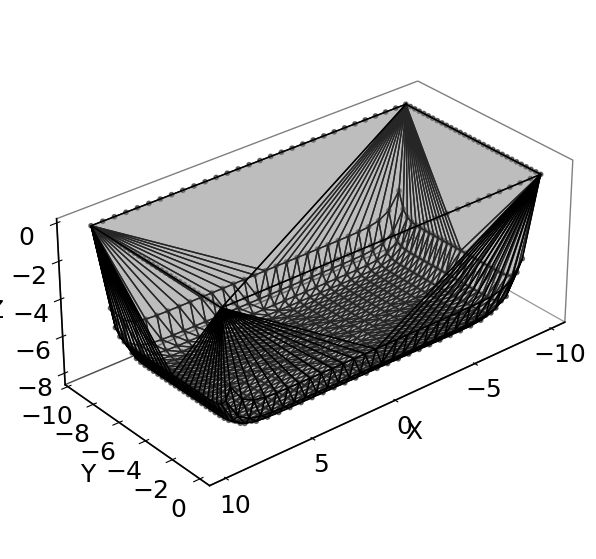

In [176]:
design = lib_RFdesign.ConvexBackshort(model_path=model_paths[0])
step_info = design.genStepBackshort(step_heights=(2.0, 1.5, 1.0), shrink=1.5)
design.plotStepBackshort3D(step_info)

# original smooth backshort example (commented coexistence)
# convex_backshort = design.genBackshort()
# design.plotConvex3D(convex_backshort)


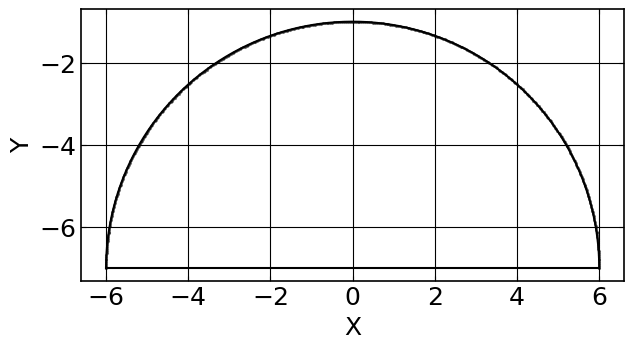

In [177]:
design = lib_RFdesign.ConvexFinshape(model_path=model_paths[1])
convex_finshpe = design.genFinshape()
design.plotProfile2D(convex_finshpe)

In [178]:
RESULTS_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_output"]))
TEMP_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"]))

In [179]:
def getResult(input_params, param_names, temp_hfss_path, result_file_path):
    df_temp = pd.read_csv(temp_hfss_path)
    header_flag = not os.path.exists(result_file_path)
    
    try:
        s11_value = df_temp.iloc[-1, -1]
        result_row = dict(zip(param_names, input_params))
        result_row["S11"] = s11_value

        df_result = pd.DataFrame([result_row]) # jissainiha kokowo w/o csv de all data fame demo OK
        df_result.to_csv(result_file_path, mode='a', header=header_flag, index=False) # append master file

        try:
            os.remove(temp_hfss_path)
        except OSError:
            pass
        return True
        
    
    except Exception as e:
        print(f"[Error][getResult] Failed to process result: {e}")
        return False

In [180]:
# --- A. HFSS ---
def target_hfss(_config_temp, sim_id, param_names, params):
    backbone.call_subroutine(_config_temp, sim_id, param_names, params, value_fmt="{:.3f}")
    getResult(params, param_names, TEMP_FILE, RESULTS_FILE)
    df_result = pd.read_csv(RESULTS_FILE)
    return df_result.iloc[-1]['S11'] # <--- should be defined as objective param

# --- B. Synthetic Test Function ---
def target_ackley(params):
    
    # --- 2. Calculation ---
    x = np.array(params)
    n = len(params)

    arg1 = -0.2 * np.sqrt((1.0/n) * np.sum(x**2))
    arg2 = (1.0/n) * np.sum(np.cos(2. * np.pi * x))
    
    y = -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

    return y

def target_add(params):

    x = np.array(params)

    y = np.sum(params)

    return y

def target_griewank(params):
    
    x = np.array(params)
    n = len(params)

    sum_term = np.sum(x**2) / 4000.0

    indices = np.arange(1, n + 1)
    prod_term = np.prod(np.cos(x / np.sqrt(indices)))
    
    y = 1.0 + sum_term - prod_term
    
    return y

costFunction = target_add
costFunction = target_ackley
costFunction = target_griewank
costFunction = target_hfss

# =====================================
if costFunction == target_hfss:
    cfg = app_config.hfss
elif costFunction == target_ackley:
    cfg = app_config.test
elif costFunction == target_add:
    cfg = app_config.test
elif costFunction == target_griewank:
    cfg = app_config.test


LOWER_BOUNDS = cfg.lower_bounds
UPPER_BOUNDS = cfg.upper_bounds
PARAM_NAMES = cfg.param_names
N_REPT = cfg.n_repeats
N_INIT = cfg.n_init
N_OPTM = cfg.n_simulation - cfg.n_init


In [181]:
if cfg.n_simulation <= cfg.n_init:
    raise ValueError("n_simulation must be greater than n_init.")

In [182]:
backbone._get_path_models()[0]

[WindowsPath('T:/RAkizawa/HFSS_C2WR10/src/0317195337/Backshort.step'),
 WindowsPath('T:/RAkizawa/HFSS_C2WR10/src/0317195337/Finshape.step')]

In [183]:
_config_temp = {
"n_simulation": cfg.n_simulation,
"n_repeats": cfg.n_repeats,
#"param_names": cfg.param_names[:4],
#"param_units": cfg.param_units[:4],
"WATCH_DIR": str(backbone._get_dir_run()),
"INPUT_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_input"])),
"MODEL_FILE": model_paths_str,
"RESULTS_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_output"])),
"TEMP_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"])),
"DONE_FLAG_FILE": str(backbone._get_dir_run() / Path("hfss.done")),
}

done_flag_path = Path(_config_temp["DONE_FLAG_FILE"])
done_flag_path.unlink(missing_ok=True)

with open(base_dir / Path("_config_HFSS.json"), 'w') as f:
        json.dump(_config_temp , f, indent=4)

print(f"Temporarily updated '{base_dir / Path("_config_HFSS.json")}' with run-specific WATCH_DIR for HFSS.")

Temporarily updated 'T:\RAkizawa\HFSS_C2WR10\src\_config_HFSS.json' with run-specific WATCH_DIR for HFSS.


In [184]:
def costFunctionWrapper(param_names, params,):

    params = np.array(params).flatten()
    sim_id = backbone._getSimulationID()
    
    y = costFunction(_config_temp, sim_id, param_names, params,)
       
    # output
    _newline = dict(zip(param_names, params))
    _newline['S11'] = y

    return y, _newline

In [185]:
# Optimizer

SEARCH_METHOD = "gradient"
optimizer = build_optimizer(SEARCH_METHOD, app_config)

def _build_hidden_row(row, routine_idx, method_name):
    hidden_row = dict(row)
    hidden_row["routine_idx"] = routine_idx
    hidden_row["method"] = method_name
    hidden_row["visibility"] = "hidden"
    return hidden_row


def _save_hidden_history(debug_rows, repeat_idx):
    if not debug_rows:
        return None

    df_debug = pd.DataFrame(debug_rows)
    csv_path = backbone._get_dir_run() / f"debug_repeat_{repeat_idx}.csv"
    df_debug.to_csv(csv_path, index=False)
    print(f"Saved hidden debug rows to: {csv_path}")
    return csv_path


def optBySearch(n_optm, history_data, visible_history, hidden_history, lower_bound, upper_bound, active_indices=None, fixed_point=None):

    for i in range(n_optm):
        routine_idx = i + 1
        remaining_before = n_optm - i
        remaining_after = n_optm - routine_idx

        print(
            f"[grad routine] entering {routine_idx}/{n_optm} "
            f"(remaining incl. this: {remaining_before}, remaining after: {remaining_after})"
        )

        x_new, info = optimizer.search(
            history_data=history_data,
            param_names=PARAM_NAMES,
            lower_bounds=lower_bound,
            upper_bounds=upper_bound,
            objective_func=costFunctionWrapper,
            active_indices=active_indices,
            fixed_point=fixed_point,
            routine_index=routine_idx,
            routine_total=n_optm,
        )

        method_name = info.get('method', SEARCH_METHOD)

        for row in info.get('evaluated_rows', []):
            history_data.append(row)
            hidden_history.append(_build_hidden_row(row, routine_idx, method_name))

        y_new, _newline = costFunctionWrapper(PARAM_NAMES, x_new)

        _newline['Metric'] = info.get('acq', info.get('base_y', np.nan))
        _newline['gamma'] = info.get('gamma', info.get('length_scale', np.nan))
        _newline['routine_idx'] = routine_idx
        history_data.append(_newline)
        visible_history.append(_newline)

        print(
            f"[grad routine] exited {routine_idx}/{n_optm} "
            f"(remaining: {remaining_after})"
        )
        print(f"{routine_idx:<5} | {y_new.item():.6f}   | {method_name:<10} | {info.get('gamma', info.get('length_scale', np.nan))}")



In [186]:
my_best_input = [
    [-9.04, 2.42, 2.22, 3.29, 2.00,],
    #[-8.77, 2.59, 2.22, 3.24, 2.00,],
    #[-8.58, 2.68, 2.21, 3.22, 1.95,],
]

backbone.all_in_bounds(my_best_input, cfg.lower_bounds, cfg.upper_bounds)
active_indices, fixed_point, _ = backbone._buildSamplingIndices(dims=cfg.n_params, param_groups=cfg.param_groups, group_order=getattr(cfg, "group_order", None),)

print("Active Indices:", active_indices)
print("Fixed Point:", fixed_point)

try:
    
    for r in range(N_REPT):
        backbone.printn(f"Starting {SEARCH_METHOD} Repeat {r + 1}/{N_REPT}")
        history_data = []
        visible_history = []
        hidden_history = []
        
        # -------------------- initial simulation --------------------------------
        backbone.printn(f"--- Generating {N_INIT} Initial Samples ---")
        
        X_initial = backbone.LHSsampler_extended(
            dims=cfg.n_params,
            nums=cfg.n_init,
            lower_bounds=cfg.lower_bounds,
            upper_bounds=cfg.upper_bounds,
            active_indices=active_indices,
            fixed_point=fixed_point,
            fixed_points = my_best_input # you can also reduce the dim of  my best_input[Ninit:]
        )
        
        print(f"{'Iter':<5} | {'New y':<10} | {'Method':<10} | {'Metric'}")        
        for i in range(N_INIT):
            params = X_initial[i]
            y_new, _newline = costFunctionWrapper(PARAM_NAMES, params,)
            _newline['Metric'] = np.nan
            _newline['gamma'] = np.nan
            _newline['routine_idx'] = 0
            history_data.append(_newline)
            visible_history.append(_newline)


        # -------------------- Search --------------------------------
        optBySearch(
            N_OPTM,
            history_data,
            visible_history,
            hidden_history,
            LOWER_BOUNDS,
            UPPER_BOUNDS,
            active_indices=active_indices,
            fixed_point=fixed_point,
        )

        # ==============================================================================
        df_final = pd.DataFrame(visible_history)
        X_train = df_final[PARAM_NAMES].values
        y_train = df_final['S11'].values

        best_idx_final = np.argmin(y_train)
        print("-" * 75)
        print(f"Optimization Finished.")
        print(f"Global Best Found: y = {y_train[best_idx_final]:.6f}")
        
        best_x_str = np.array2string(X_train[best_idx_final], precision=4, separator=', ')
        print(f"At location: x = {best_x_str}")
        
        # --- After each repeat, archive results and save plot data ---
        df_output = backbone._genOutputDataFrame(df_final)
        _save_hidden_history(hidden_history, r + 1)
        
        # save
        backbone._addNewDatasetToHDF(df_output, "output", f"repeat_{r+1}")
        
        # --- 5a. Visualize learning curve of the final model ---
        plot.plot_learning_curve(df_output)
                
finally:
    done_flag_path = Path(_config_temp["DONE_FLAG_FILE"])
    done_flag_path.touch()

    json_file = base_dir / Path("_config_HFSS.json")
    json_file.unlink(missing_ok=True) # delite the json file
    if backbone.h5f:
        backbone.h5f.close()



Active Indices: [2, 3, 4]
Fixed Point: [-6.  3.  4.  6.  2.]

Starting GP Repeat 1/1

--- Generating 15 Initial Samples ---
Iter  | New y      | Gamma    | x_acq    | New x


KeyboardInterrupt: 